In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf # pip install yfinance

In [11]:
tickers = [
    "AIRR", "SPY", "SCHG", "VUG", "MGK", "XLY", "IYW", "PSI", "FDN", "IGM",
    "FTEC", "XLK", "VGT", "SOXX", "GLD", "XAR", "VPU", "XLV", "PHO", "ARKW"
]

data = yf.download(
    tickers,
    start="2010-12-01",
    end="2026-01-01",   # includes data up to 2025-12-31
    interval="1d",
    auto_adjust=False,
    progress=False
)

# we use adjusted closing prices
monthly_prices = data["Adj Close"].resample("M").last()

# Month to month returns
# dropna(how="any") keeps only months where all ETFs have valid returns
monthly_ROR = monthly_prices.pct_change().dropna(how="any")

# 60/40 train test split using all available common data
T = len(monthly_ROR)
split_idx = int(0.6 * T)

monthly_ROR_train = monthly_ROR.iloc[:split_idx]
monthly_ROR_test = monthly_ROR.iloc[split_idx:]

# rows = assets, columns = scenarios/months
# R[j,t] = return of asset j in scenario/month t
R_train = monthly_ROR_train.T
R_test = monthly_ROR_test.T
R_full = monthly_ROR.T

print("Full period:", monthly_ROR.index.min().date(), "to", monthly_ROR.index.max().date())
print("Train period:", monthly_ROR_train.index.min().date(), "to", monthly_ROR_train.index.max().date())
print("Test period:", monthly_ROR_test.index.min().date(), "to", monthly_ROR_test.index.max().date())

print("R_train shape:", R_train.shape)
print("R_test shape:", R_test.shape)
print("R_full shape:", R_full.shape)

R_train.to_csv("monthly_ROR_train.csv", index=True)
R_test.to_csv("monthly_ROR_test.csv", index=True)
R_full.to_csv("monthly_ROR_full.csv", index=True)



Full period: 2014-10-31 to 2025-12-31
Train period: 2014-10-31 to 2021-06-30
Test period: 2021-07-31 to 2025-12-31
R_train shape: (20, 81)
R_test shape: (20, 54)
R_full shape: (20, 135)


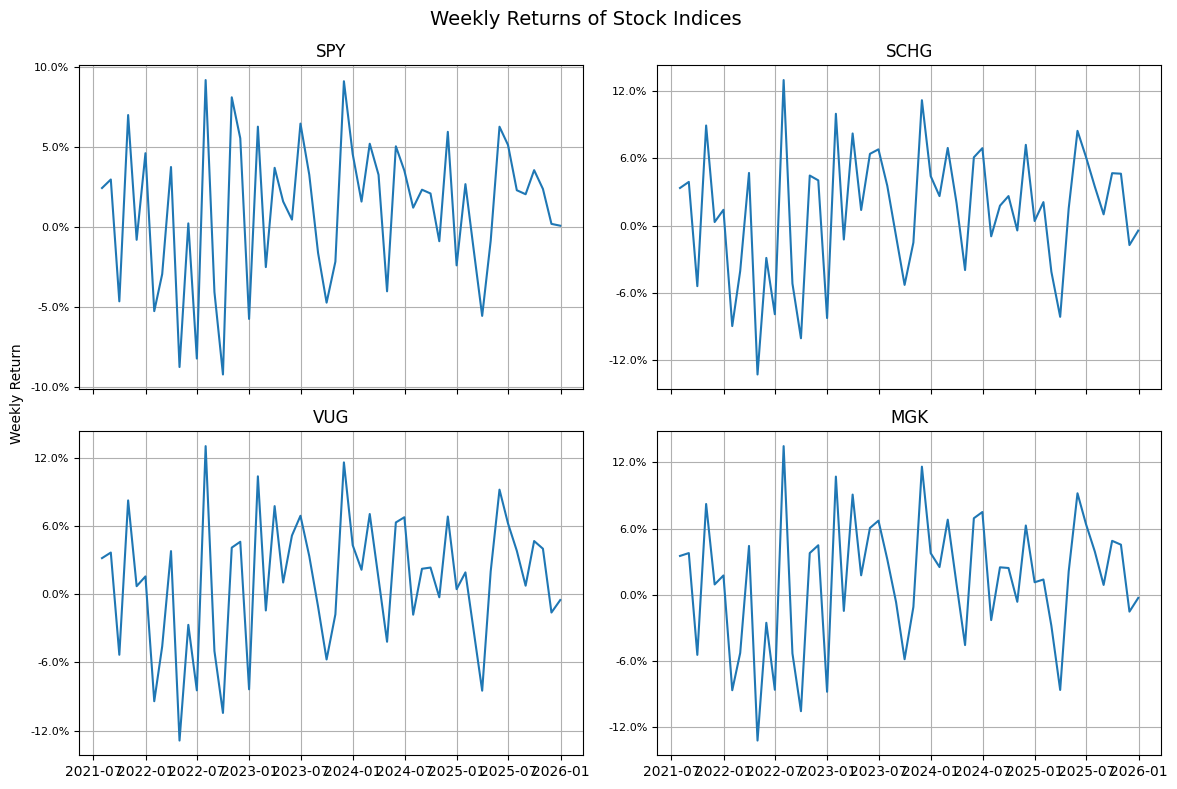

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.flatten()

for i, ticker in enumerate(tickers[1:5]):  # plot the first 4 tickers for better visibility
    axes[i].plot(monthly_ROR_test.index, monthly_ROR_test[ticker])
    axes[i].set_title(ticker)
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(5))
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].grid()

fig.suptitle("Weekly Returns of Stock Indices", fontsize=14)
fig.supylabel("Weekly Return", fontsize=10)  # single shared y label
plt.tight_layout()
plt.show()